In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


DATA_PATH = Path("../data/raw/RML2016.10a/RML2016.10a_dict.pkl")

with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(f, encoding="latin1")

print(f"Dataset cargado: {len(radioml)} combinaciones")

Dataset cargado: 220 combinaciones


In [2]:
def get_signal(radioml, modulation, snr, sample_index=0):
    """Return I, Q and complex representation of one RadioML sample."""
    sample = radioml[(modulation, snr)][sample_index]

    I = sample[0]
    Q = sample[1]
    complex_signal = I + 1j * Q

    return I, Q, complex_signal


def plot_signal_overview(radioml, modulation, snr, sample_index=0):
    """Plot I/Q, magnitude, phase and I/Q representation."""
    
    I, Q, complex_signal = get_signal(
        radioml, modulation, snr, sample_index
    )

    magnitude = np.abs(complex_signal)
    phase = np.angle(complex_signal)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # I and Q
    axes[0, 0].plot(I, label="I")
    axes[0, 0].plot(Q, label="Q")
    axes[0, 0].set_title("I/Q over time")
    axes[0, 0].set_xlabel("Sample")
    axes[0, 0].set_ylabel("Amplitude")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Magnitude
    axes[0, 1].plot(magnitude)
    axes[0, 1].set_title("Magnitude")
    axes[0, 1].set_xlabel("Sample")
    axes[0, 1].set_ylabel("Magnitude")
    axes[0, 1].grid(True)

    # Phase
    axes[1, 0].plot(phase)
    axes[1, 0].set_title("Phase")
    axes[1, 0].set_xlabel("Sample")
    axes[1, 0].set_ylabel("Phase [rad]")
    axes[1, 0].grid(True)

    # I/Q representation
    axes[1, 1].scatter(I, Q, s=15, alpha=0.7)
    axes[1, 1].set_title("I/Q representation")
    axes[1, 1].set_xlabel("I")
    axes[1, 1].set_ylabel("Q")
    axes[1, 1].axis("equal")
    axes[1, 1].grid(True)

    fig.suptitle(
        f"{modulation} — SNR = {snr} dB",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


def plot_psd(radioml, modulation, snr, sample_index=0):
    """Plot the power spectral density of one RadioML sample."""
    
    _, _, complex_signal = get_signal(
        radioml, modulation, snr, sample_index
    )

    frequencies, psd = welch(
        complex_signal,
        nperseg=128,
        return_onesided=False
    )

    frequencies = np.fft.fftshift(frequencies)
    psd = np.fft.fftshift(psd)

    psd_db = 10 * np.log10(psd + 1e-12)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(frequencies, psd_db)
    ax.set_title(f"PSD — {modulation}, SNR = {snr} dB")
    ax.set_xlabel("Normalized frequency")
    ax.set_ylabel("PSD [dB]")
    ax.grid(True)

    plt.show()

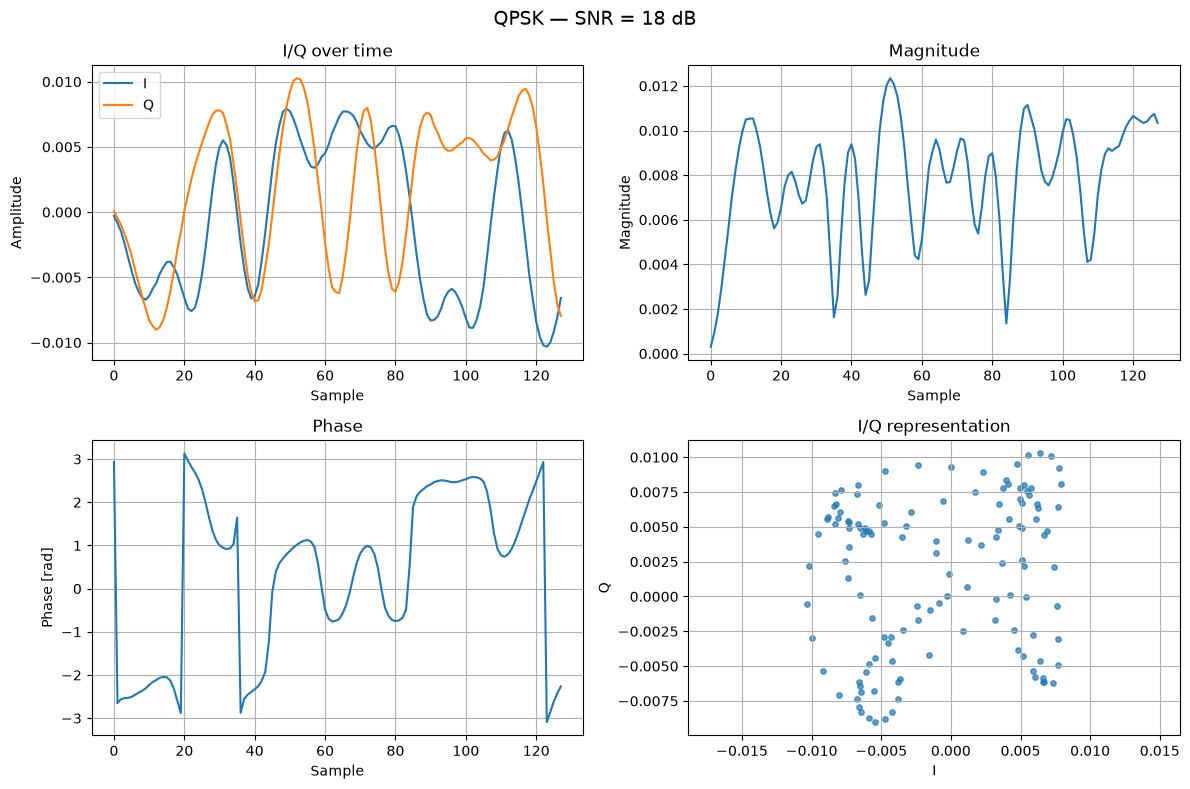

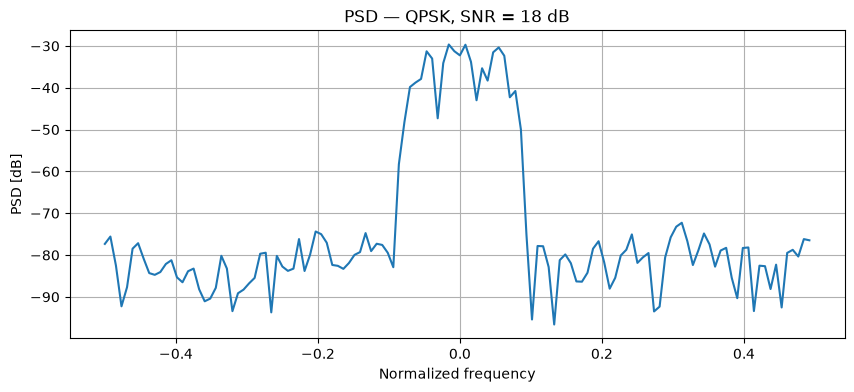

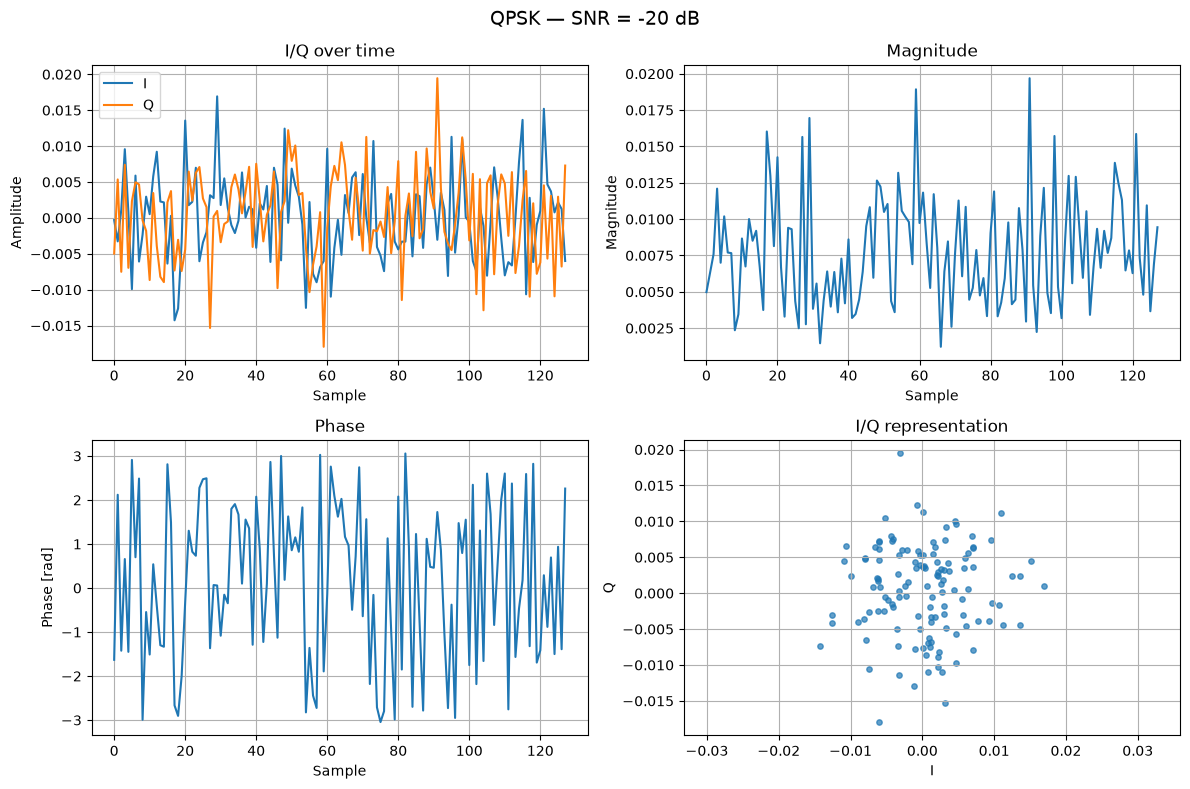

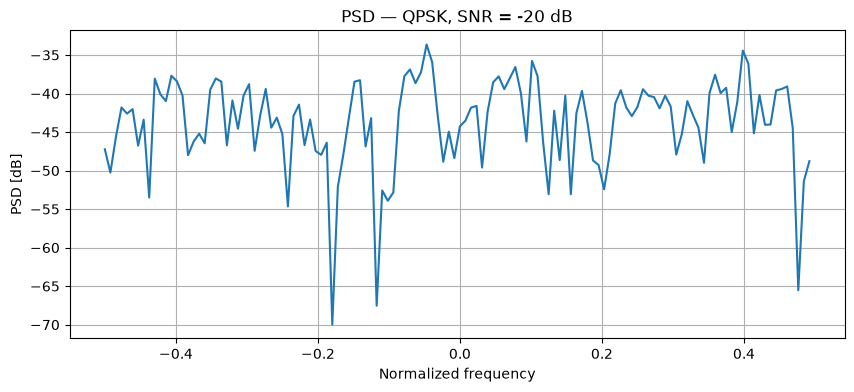

In [3]:
modulation = "QPSK"
sample_index = 0

for snr in [18, -20]:
    plot_signal_overview(
        radioml,
        modulation=modulation,
        snr=snr,
        sample_index=sample_index
    )

    plot_psd(
        radioml,
        modulation=modulation,
        snr=snr,
        sample_index=sample_index
    )

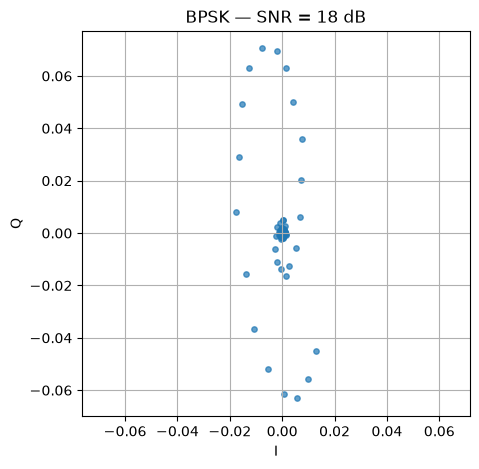

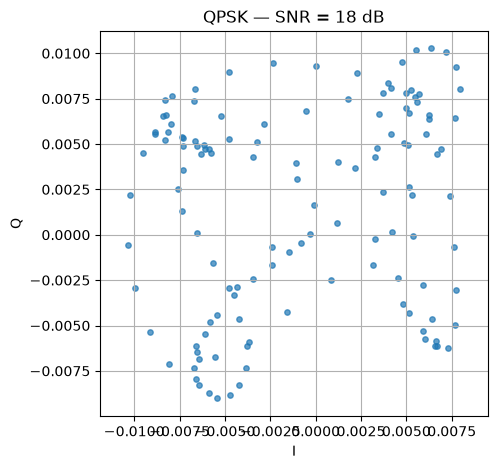

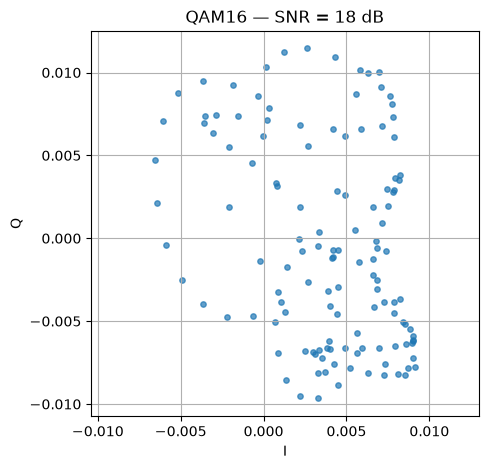

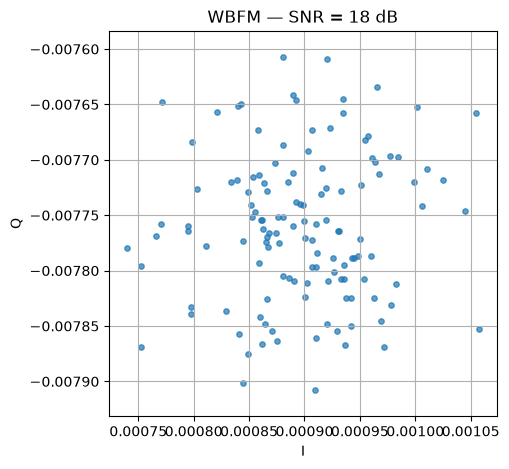

In [4]:
modulations_to_compare = ["BPSK", "QPSK", "QAM16", "WBFM"]
comparison_snr = 18
sample_index = 0

for modulation in modulations_to_compare:
    I, Q, _ = get_signal(
        radioml,
        modulation,
        comparison_snr,
        sample_index
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(I, Q, s=15, alpha=0.7)

    ax.set_title(f"{modulation} — SNR = {comparison_snr} dB")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.axis("equal")
    ax.grid(True)

    plt.show()